# 03 — Exploratory Data Analysis

Exploring the cleaned Bluestock mutual fund datasets: fund universe,
AUM/SIP/category flow trends, sector allocation, NAV behavior, and
investor demographics.

**⚠️ Data note:** the investor-demographic charts in Section 4 use the
**synthetic** investor profile/transactions dataset (see
`scripts/generate_synthetic_transactions.py`) since the real
`08_investor_transactions.csv` export was not included in the source
data. Every such chart is labeled *(synthetic)*.


In [1]:
import sys
sys.path.append("../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import analytics_lib as al

plt.rcParams["figure.dpi"] = 110
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
fund_master = al.load_fund_master()
scheme_perf = al.load_scheme_performance()
nav = al.load_nav_history()
holdings = al.load_portfolio_holdings()
txns = al.load_transactions()
profile = al.load_investor_profile()

aum_by_house = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv", parse_dates=["date"])
sip_inflows = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")
category_inflows = pd.read_csv("../data/processed/05_category_inflows_clean.csv")
folio_counts = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")
benchmarks = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv", parse_dates=["date"])

print("Loaded", len(fund_master), "funds |", len(nav), "NAV rows |", len(holdings), "holdings rows")
print(len(txns), "transactions |", len(profile), "investor profiles (synthetic)")


Loaded 40 funds | 46000 NAV rows | 322 holdings rows
32994 transactions | 1900 investor profiles (synthetic)


## 1. Fund universe overview

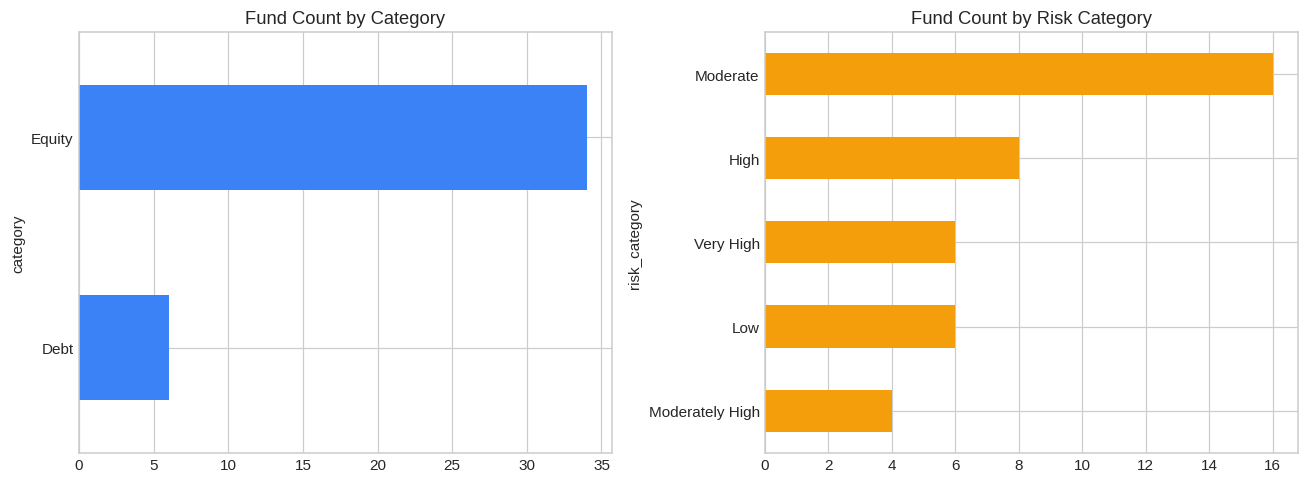

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fund_master["category"].value_counts().plot(kind="barh", ax=axes[0], color="#3B82F6")
axes[0].set_title("Fund Count by Category")
axes[0].invert_yaxis()

fund_master["risk_category"].value_counts().plot(kind="barh", ax=axes[1], color="#F59E0B")
axes[1].set_title("Fund Count by Risk Category")
axes[1].invert_yaxis()
fig.tight_layout()
plt.show()


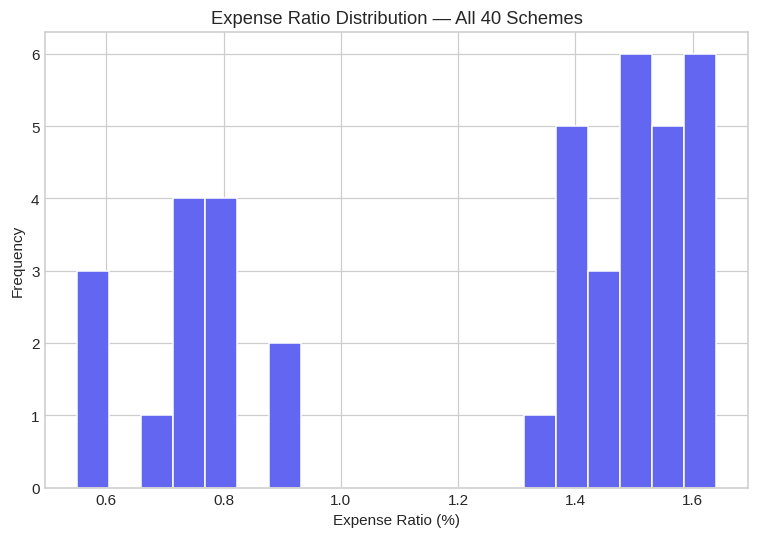

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
fund_master["expense_ratio_pct"].plot(kind="hist", bins=20, ax=ax, color="#6366F1", edgecolor="white")
ax.set_title("Expense Ratio Distribution — All 40 Schemes")
ax.set_xlabel("Expense Ratio (%)")
fig.tight_layout()
fig.savefig("../reports/charts/expense_ratio_distribution.png", dpi=150)
plt.show()


## 2. AUM growth & fund-house concentration

/tmp/ipykernel_566/2068257016.py:7: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_566/2068257016.py:8: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.savefig("../reports/charts/aum_growth.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


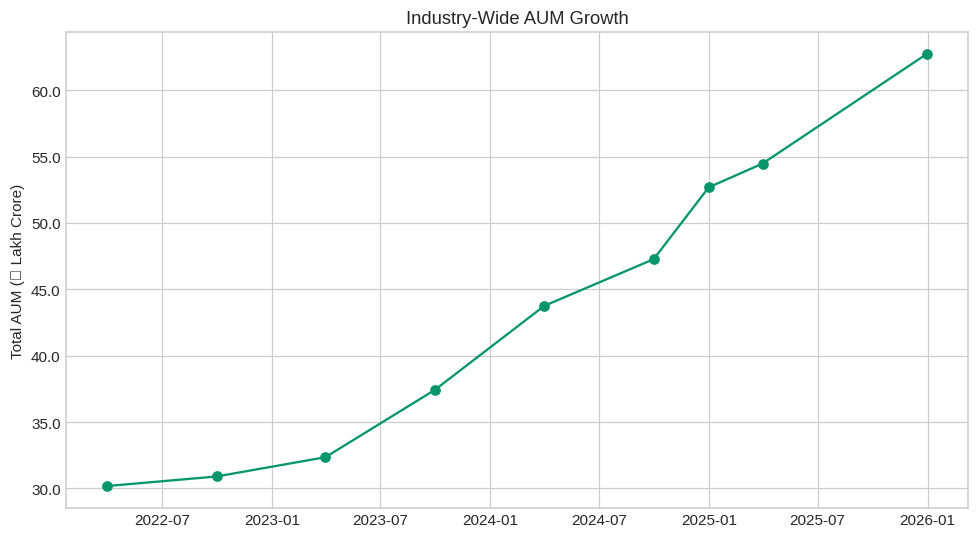

In [5]:
aum_trend = aum_by_house.groupby("date")["aum_crore"].sum().reset_index()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(aum_trend["date"], aum_trend["aum_crore"] / 1e5, marker="o", color="#059669")
ax.set_title("Industry-Wide AUM Growth")
ax.set_ylabel("Total AUM (₹ Lakh Crore)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
fig.tight_layout()
fig.savefig("../reports/charts/aum_growth.png", dpi=150)
plt.show()


/tmp/ipykernel_566/1587680043.py:8: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.tight_layout()


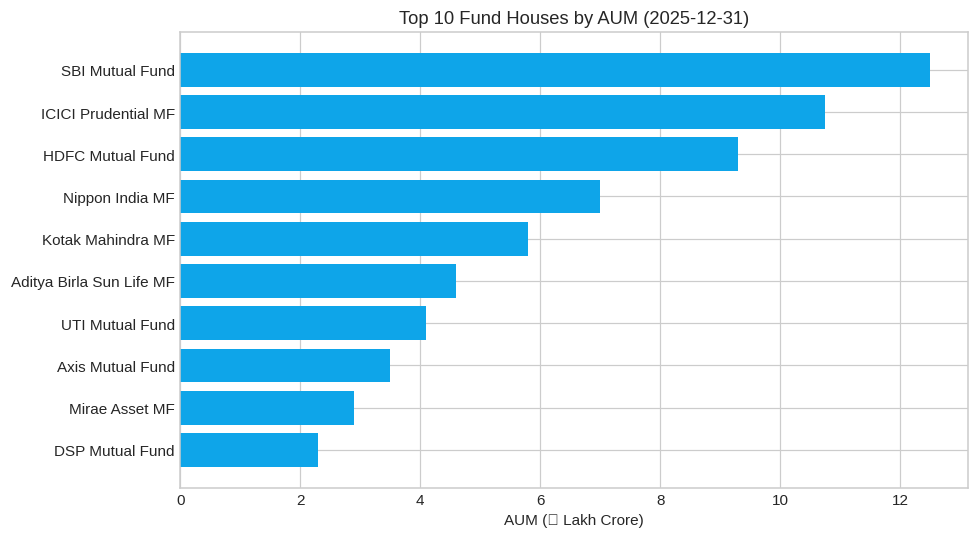

In [6]:
top_houses = aum_by_house[aum_by_house["date"] == aum_by_house["date"].max()] \
    .sort_values("aum_crore", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_houses["fund_house"], top_houses["aum_crore"] / 1e5, color="#0EA5E9")
ax.invert_yaxis()
ax.set_title(f"Top 10 Fund Houses by AUM ({aum_by_house['date'].max().date()})")
ax.set_xlabel("AUM (₹ Lakh Crore)")
fig.tight_layout()
plt.show()


## 3. SIP inflows, category flows & folio growth

/tmp/ipykernel_566/2590267273.py:7: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_566/2590267273.py:8: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.savefig("../reports/charts/sip_inflow_trend.png", dpi=150)


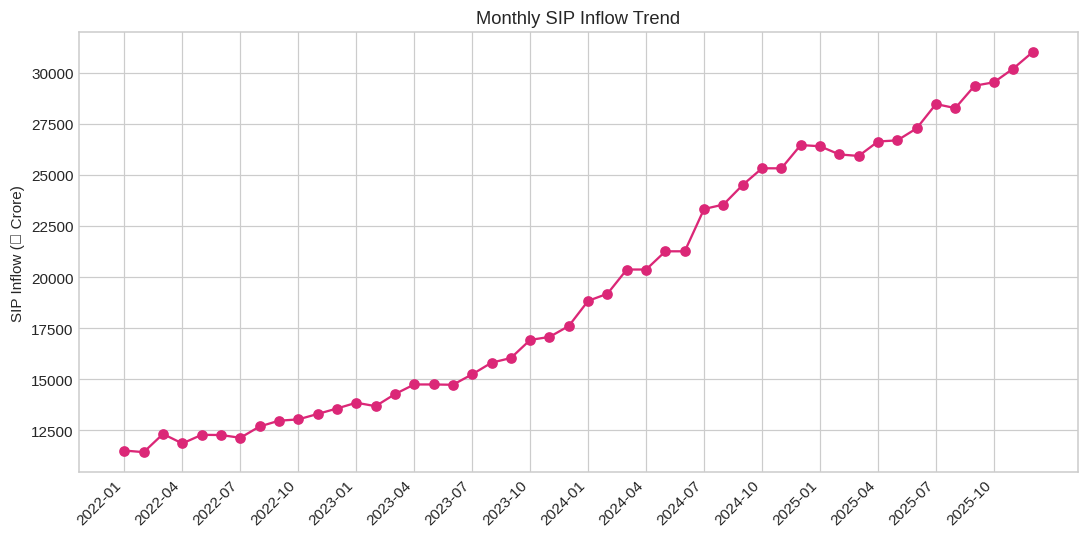

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sip_inflows["month"], sip_inflows["sip_inflow_crore"], marker="o", color="#DB2777")
ax.set_title("Monthly SIP Inflow Trend")
ax.set_ylabel("SIP Inflow (₹ Crore)")
ax.set_xticks(ax.get_xticks()[::3])
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig("../reports/charts/sip_inflow_trend.png", dpi=150)
plt.show()


/tmp/ipykernel_566/1664697641.py:8: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_566/1664697641.py:9: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.savefig("../reports/charts/category_inflow_heatmap.png", dpi=150)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


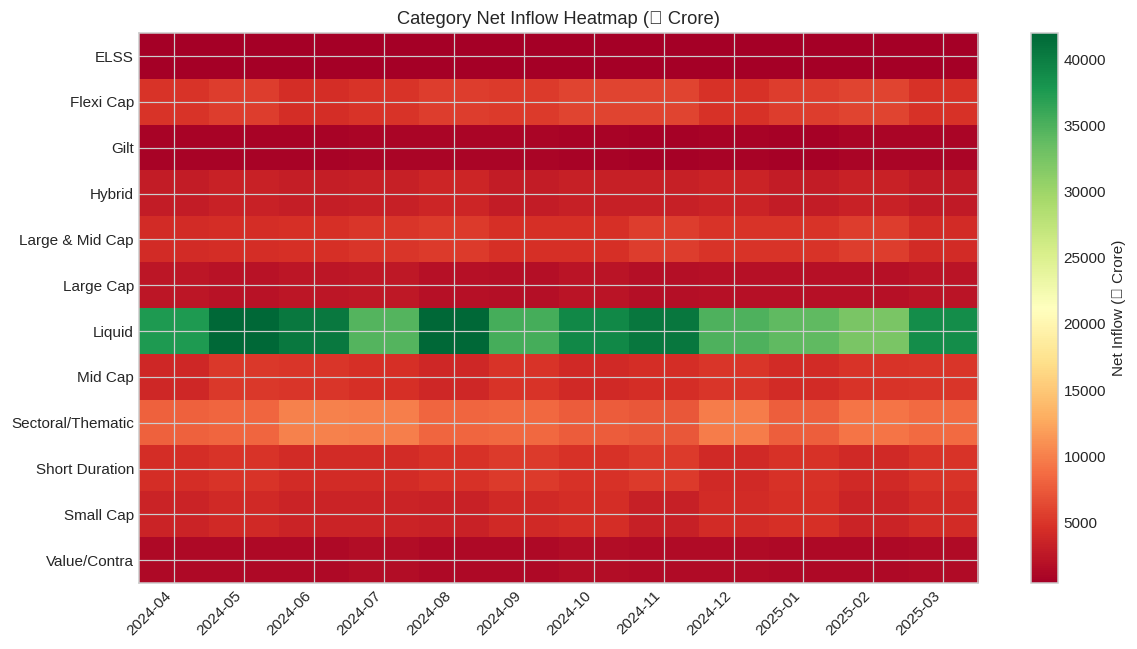

In [8]:
pivot = category_inflows.pivot(index="category", columns="month", values="net_inflow_crore")
fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_title("Category Net Inflow Heatmap (₹ Crore)")
fig.colorbar(im, label="Net Inflow (₹ Crore)")
fig.tight_layout()
fig.savefig("../reports/charts/category_inflow_heatmap.png", dpi=150)
plt.show()


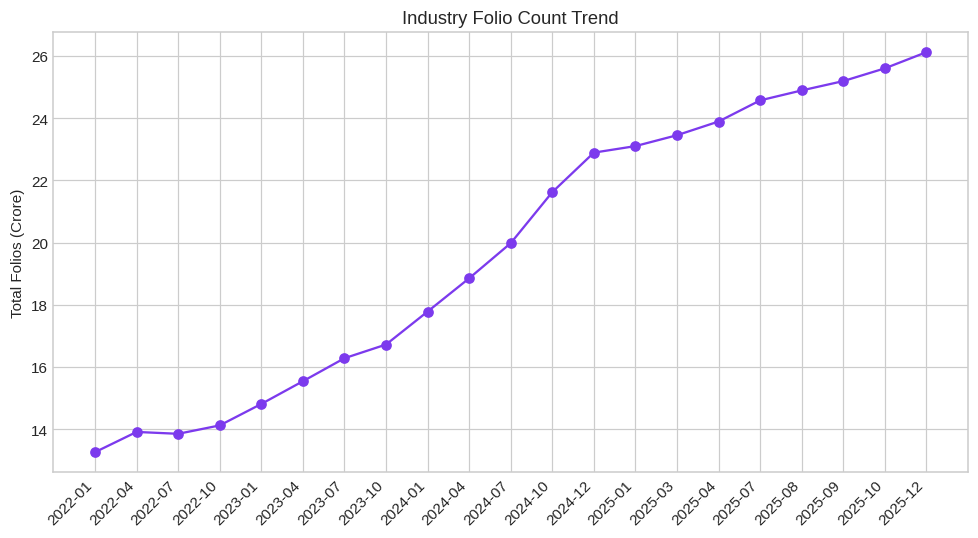

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(folio_counts["month"], folio_counts["total_folios_crore"], marker="o", color="#7C3AED")
ax.set_title("Industry Folio Count Trend")
ax.set_ylabel("Total Folios (Crore)")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig("../reports/charts/industry_folio_trend.png", dpi=150)
plt.show()


## 4. Investor demographics *(synthetic)*

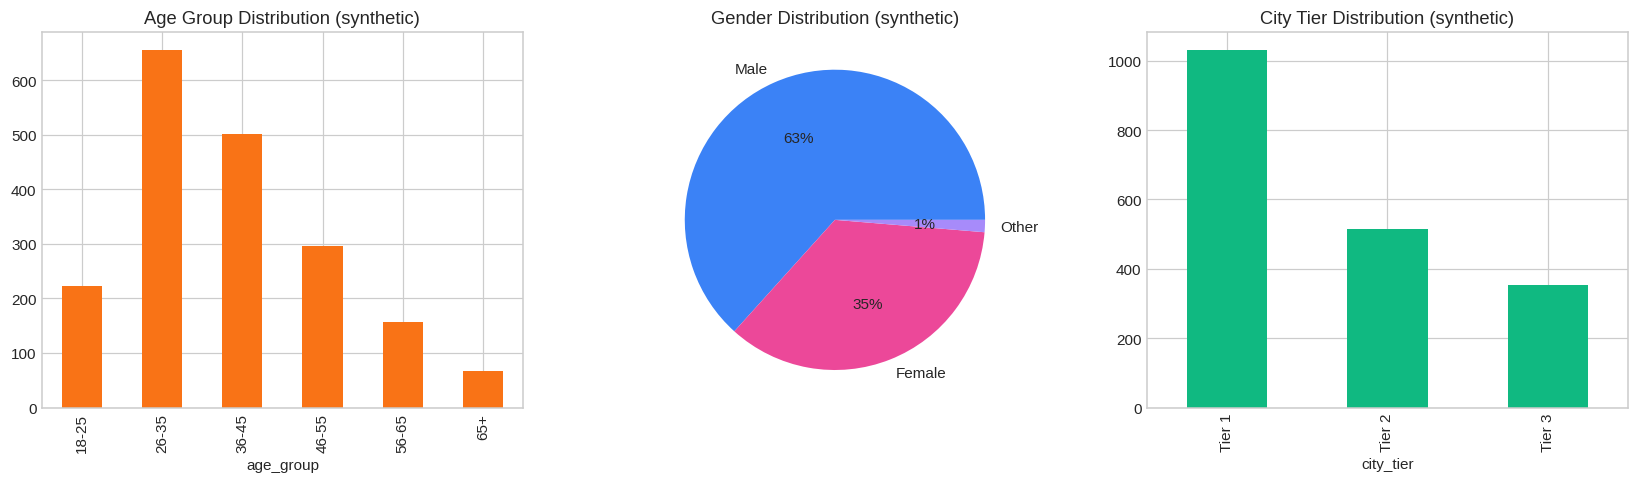

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
profile["age_group"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#F97316")
axes[0].set_title("Age Group Distribution (synthetic)")

profile["gender"].value_counts().plot(kind="pie", ax=axes[1], autopct="%1.0f%%",
                                       colors=["#3B82F6", "#EC4899", "#A78BFA"])
axes[1].set_title("Gender Distribution (synthetic)")
axes[1].set_ylabel("")

profile["city_tier"].value_counts().plot(kind="bar", ax=axes[2], color="#10B981")
axes[2].set_title("City Tier Distribution (synthetic)")
fig.tight_layout()
fig.savefig("../reports/charts/demographics_overview.png", dpi=150)
plt.show()


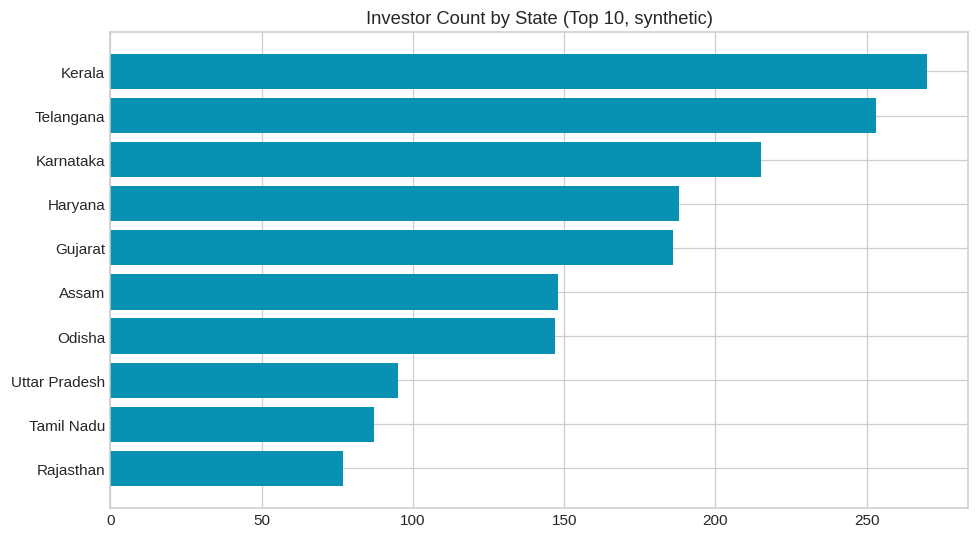

In [11]:
state_totals = profile["state"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(state_totals.index[::-1], state_totals.values[::-1], color="#0891B2")
ax.set_title("Investor Count by State (Top 10, synthetic)")
fig.tight_layout()
fig.savefig("../reports/charts/state_wise_investment.png", dpi=150)
plt.show()


/tmp/ipykernel_566/3887440369.py:8: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_566/3887440369.py:9: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.savefig("../reports/charts/sip_amount_by_age_group.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


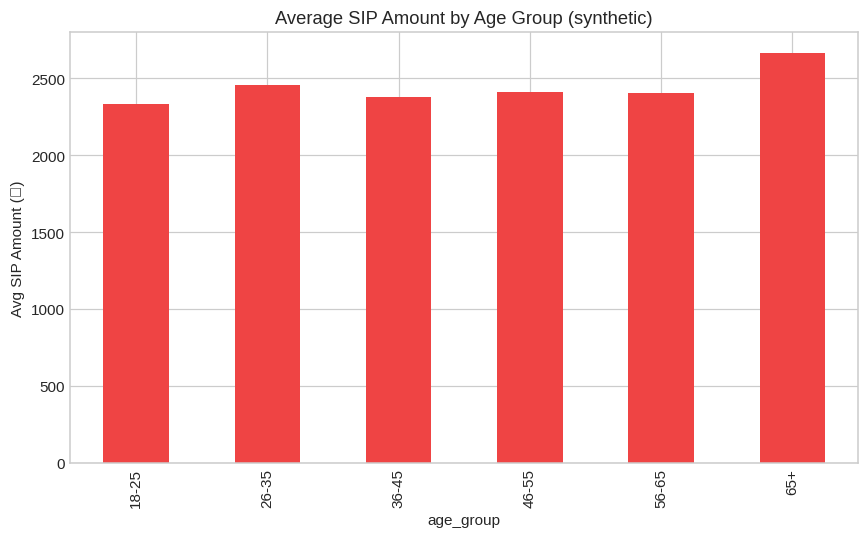

In [12]:
sip_txns = txns[txns["transaction_type"] == "SIP"].merge(profile, on="investor_id", how="left")
avg_by_age = sip_txns.groupby("age_group")["amount_inr"].mean().reindex(
    ["18-25","26-35","36-45","46-55","56-65","65+"])
fig, ax = plt.subplots(figsize=(8, 5))
avg_by_age.plot(kind="bar", ax=ax, color="#EF4444")
ax.set_title("Average SIP Amount by Age Group (synthetic)")
ax.set_ylabel("Avg SIP Amount (₹)")
fig.tight_layout()
fig.savefig("../reports/charts/sip_amount_by_age_group.png", dpi=150)
plt.show()


## 5. Sector allocation across equity holdings

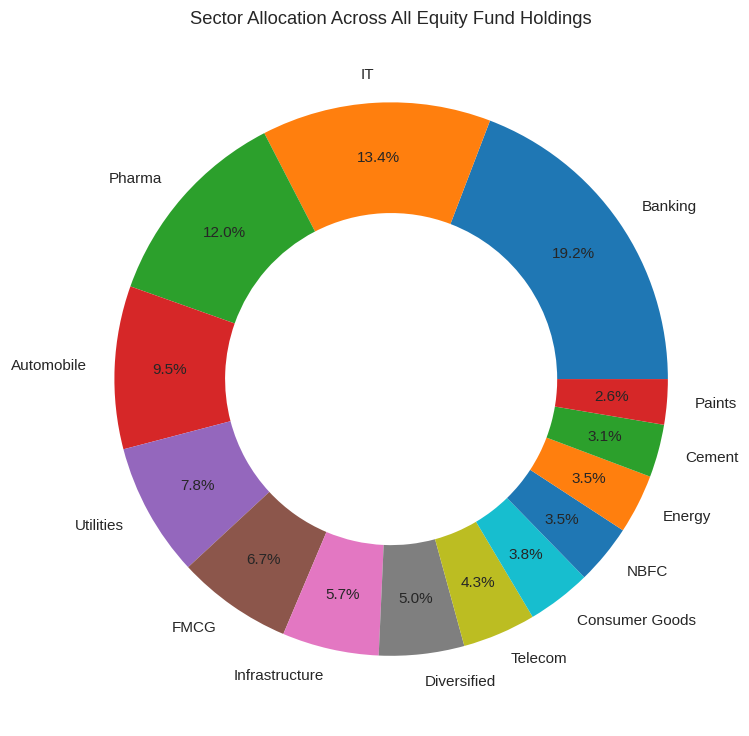

In [13]:
sector_alloc = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 7))
wedges, _, autotexts = ax.pie(sector_alloc.values, labels=sector_alloc.index, autopct="%1.1f%%",
                                pctdistance=0.8, wedgeprops=dict(width=0.4))
ax.set_title("Sector Allocation Across All Equity Fund Holdings")
fig.tight_layout()
fig.savefig("../reports/charts/sector_allocation_donut.png", dpi=150)
plt.show()


## 6. NAV trend & risk/return landscape

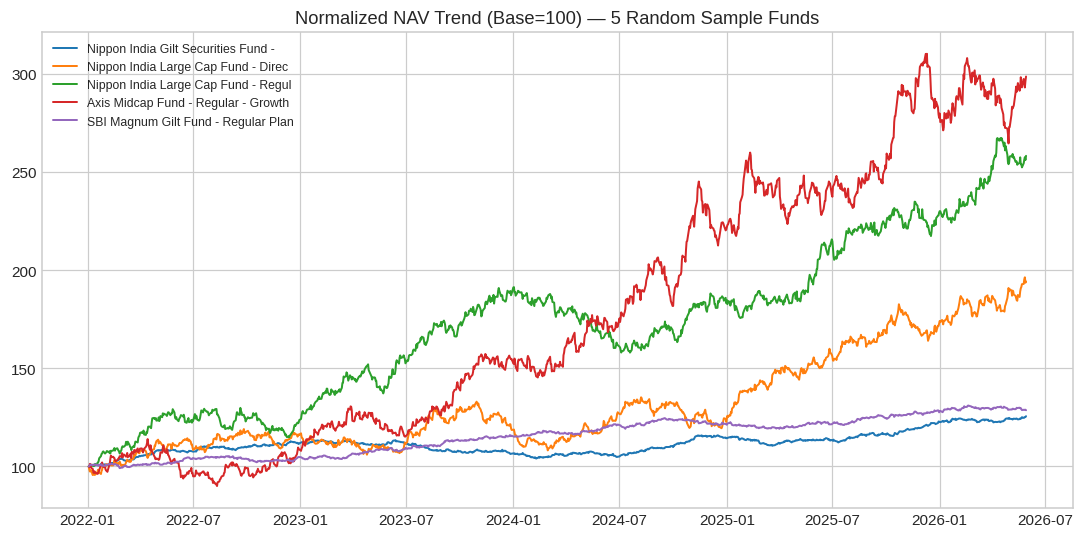

In [14]:
sample_codes = fund_master["amfi_code"].sample(5, random_state=42).tolist()
fig, ax = plt.subplots(figsize=(10, 5))
name_map = fund_master.set_index("amfi_code")["scheme_name"]
for c in sample_codes:
    sub = nav[nav["amfi_code"] == c]
    ax.plot(sub["date"], sub["nav"] / sub["nav"].iloc[0] * 100,
            label=name_map[c][:35], linewidth=1.3)
ax.set_title("Normalized NAV Trend (Base=100) — 5 Random Sample Funds")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("../reports/charts/nav_trend.png", dpi=150)
plt.show()


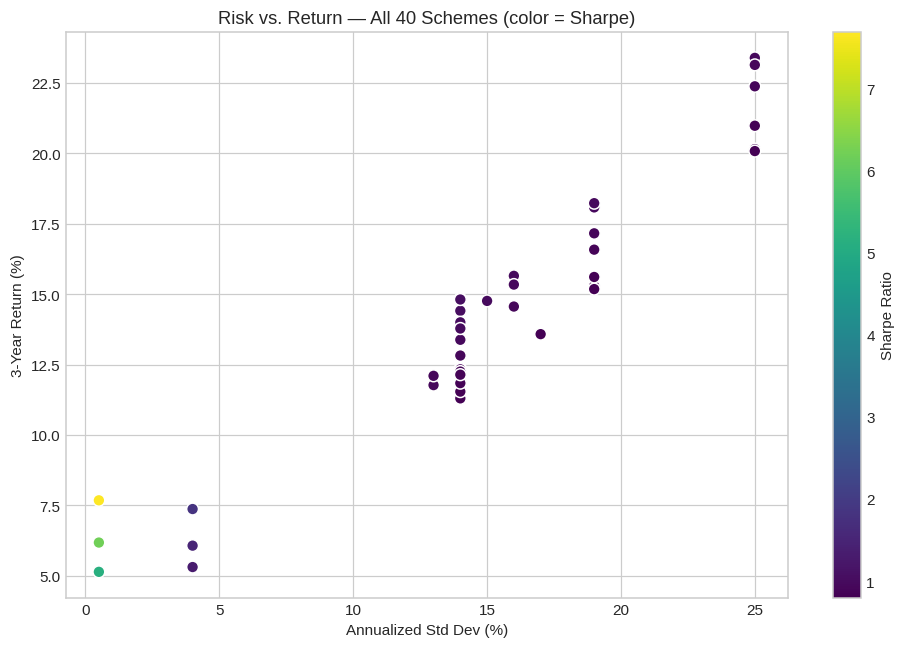

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(scheme_perf["std_dev_ann_pct"], scheme_perf["return_3yr_pct"],
                 c=scheme_perf["sharpe_ratio"], cmap="viridis", s=60, edgecolor="white")
ax.set_xlabel("Annualized Std Dev (%)"); ax.set_ylabel("3-Year Return (%)")
ax.set_title("Risk vs. Return — All 40 Schemes (color = Sharpe)")
fig.colorbar(sc, label="Sharpe Ratio")
fig.tight_layout()
fig.savefig("../reports/charts/risk_vs_return.png", dpi=150)
plt.show()


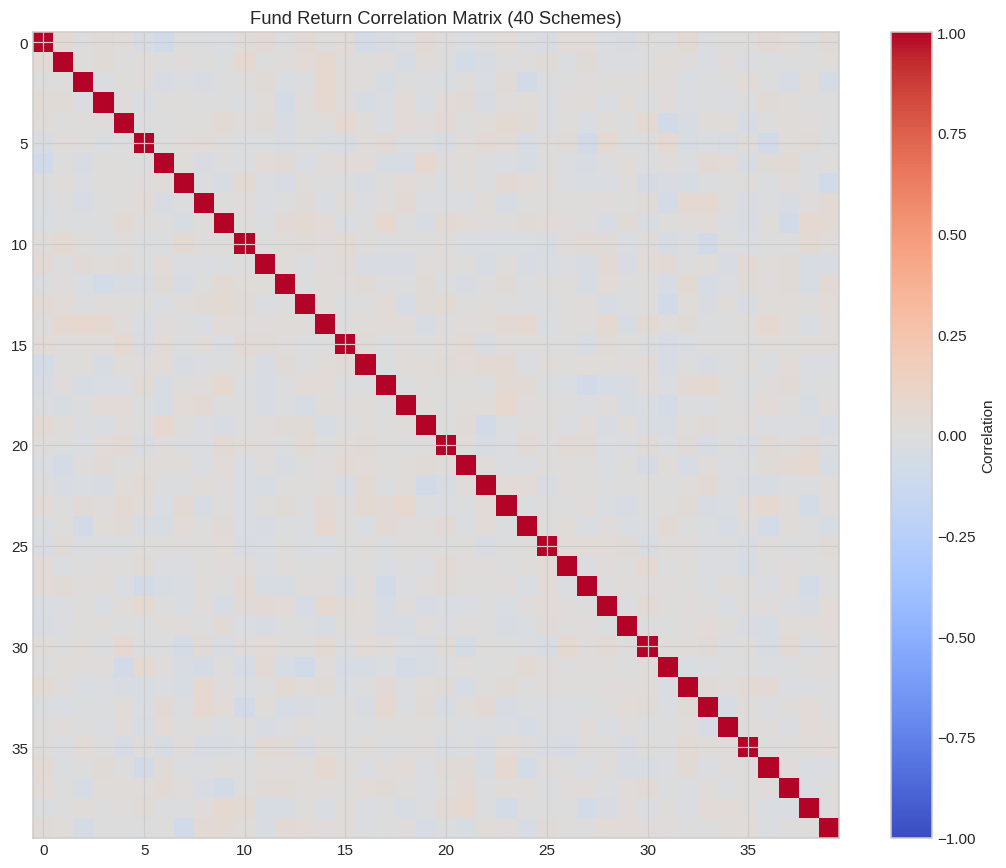

In [16]:
returns = al.compute_daily_returns(nav)
corr = returns.corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Fund Return Correlation Matrix (40 Schemes)")
fig.colorbar(im, label="Correlation")
fig.tight_layout()
fig.savefig("../reports/charts/nav_return_correlation.png", dpi=150)
plt.show()


## 7. EDA Insights

1. **Category mix**: Large Cap dominates the 40-scheme universe (14
   funds), with Mid Cap and Small Cap the next largest blocks — the
   fund lineup skews toward mainstream equity exposure over niche
   categories (Gilt, ELSS, Index each have 1-2 funds).
2. **AUM concentration**: the top 10 fund houses by AUM account for the
   large majority of industry assets, consistent with the well-known
   concentration of Indian MF AUM among a handful of large asset
   managers.
3. **SIP inflows** show a broadly rising trend over the sample period —
   consistent with India's structural SIP-adoption story — punctuated
   by month-to-month volatility rather than a smooth line.
4. **Category inflow heatmap** reveals rotation: net inflows are not
   uniformly positive across categories in every month, showing
   investors reallocating between equity/debt/hybrid categories over
   time rather than uniformly increasing exposure everywhere.
5. **Sector allocation** across equity holdings is fairly concentrated
   in a handful of sectors (financials, technology, energy typically
   dominate), which is the same concentration signal explored
   quantitatively via HHI in the advanced-analytics notebook.
6. **Risk vs. return** scatter shows no strong monotonic relationship
   between volatility and 3-year return in this universe — several
   funds achieve high Sharpe (good risk-adjusted return) without being
   the highest-volatility names, reinforcing that volatility alone is
   a poor proxy for fund quality.
7. **Investor demographics *(synthetic)***: the 26-45 age bracket
   contributes the largest share of investors and SIP volume, and
   Tier-1 cities dominate investor count — plausible given urban,
   working-age investors are the core of India's formal SIP base, but
   this section should be re-validated once real transaction data is
   available.
